# Supplementary analyses: surrogates, noise robustness, and low-rank comparison

Produces **Figs 11, 12, 16, 19** and the subsample panel of **Fig 18**. Each section is self-contained; the only cross-cell dependency is the tuning-curve helper below and the noise-sweep cache. All `plt.savefig` calls here write bare filenames into `notebooks/`, and the `.npz` cache is under `../data/`.

In [60]:
# Regeneration switches (default off so a normal run cannot overwrite committed figures/caches):
SAVE_FIGURES = False
REGENERATE_CACHES = False

import numpy as np
from ring import tc, fn, data_driven, sim
from tqdm import tqdm
import matplotlib.pyplot as plt
from ring import style
from ring import gp_opt
from ring import regression
import scipy
from scipy.stats import ortho_group
from scipy.ndimage import gaussian_filter1d
import torch

## Idealized tuning-curve model

The same erf-nonlinearity tuning-curve family used in `spectra.ipynb`, defined locally so the notebook runs standalone.

In [2]:
from ring.fn import nonlin_idealized
from ring.tc import gen_tuning_curves_idealized

def nonlin_idealized_deriv_avg(data, beta):
    result = beta * fn.unity_erf_deriv(beta * data).mean()
    return result


## Figure 12 — structured J vs. spectrum-matched surrogates

Builds the model's `J`, then a family of surrogate matrices sharing a random orthogonal basis with smoothed singular-value spectra (decay scales σ = 5–40). Sorting both by the phase of their leading two singular vectors shows that matching the spectrum reproduces the band structure but not the model's actual weights. Two seeds appear deliberately (fix F3): `rng = default_rng(42)` is a *local* generator consumed by `ortho_group.rvs`, while `np.random.seed(42)` covers the *global* state that `sample_tcs` draws from — both are needed. The explicit `V = Vt.T` is also part of F3; without it the next section raises `NameError`. Saves `real_vs_surrogate_matrices.png`.

In [ ]:
# --- params ---
N        = 2500
N_theta  = 500
beta     = 2.7659
scale    = 1.4211
lamda    = 1e-8
smooth_scales = [5, 10, 20, 40]

rng = np.random.default_rng(42)
np.random.seed(42)

# --- helpers ---
def smooth_like(s, decay_scale):
    idx = np.arange(s.size)
    env = np.exp(-0.5 * (idx / decay_scale) ** 2)
    env *= s[0] / env[0]
    return env

def sort_order_from_psi(U2):
    x, y = U2[:, 0], U2[:, 1]
    psi = np.mod(np.arctan2(y, x), 2 * np.pi)
    return np.argsort(psi)

def sort_matrix_by_order(J, order):
    return J[order, :][:, order]


# --- construct actual J and its SVD ---
X, Phi = gen_tuning_curves_idealized(N_samples=N, N_theta=N_theta,
                                     scale=scale, beta=beta)
J, J_uc = data_driven.compute_weights(X=X, Phi=Phi, lamda=lamda)

U, s, Vt = np.linalg.svd(J, full_matrices=False)
V = Vt.T

# --- shared random orthogonal basis ---
U_fake = ortho_group.rvs(N, random_state=rng)

# --- build fakes ---
s_fakes = {σ: smooth_like(s, σ) for σ in smooth_scales}
J_fakes = {σ: (U_fake @ np.diag(s_fakes[σ]) @ U_fake.T) for σ in smooth_scales}

# --- orders ---
order_real = sort_order_from_psi(U[:, :2])
order_fake = sort_order_from_psi(U_fake[:, :2])

# --- sorted matrices ---
J_real_sorted = sort_matrix_by_order(J, order_real)
J_fake_sorted = {σ: sort_matrix_by_order(J_fakes[σ], order_fake) for σ in smooth_scales}


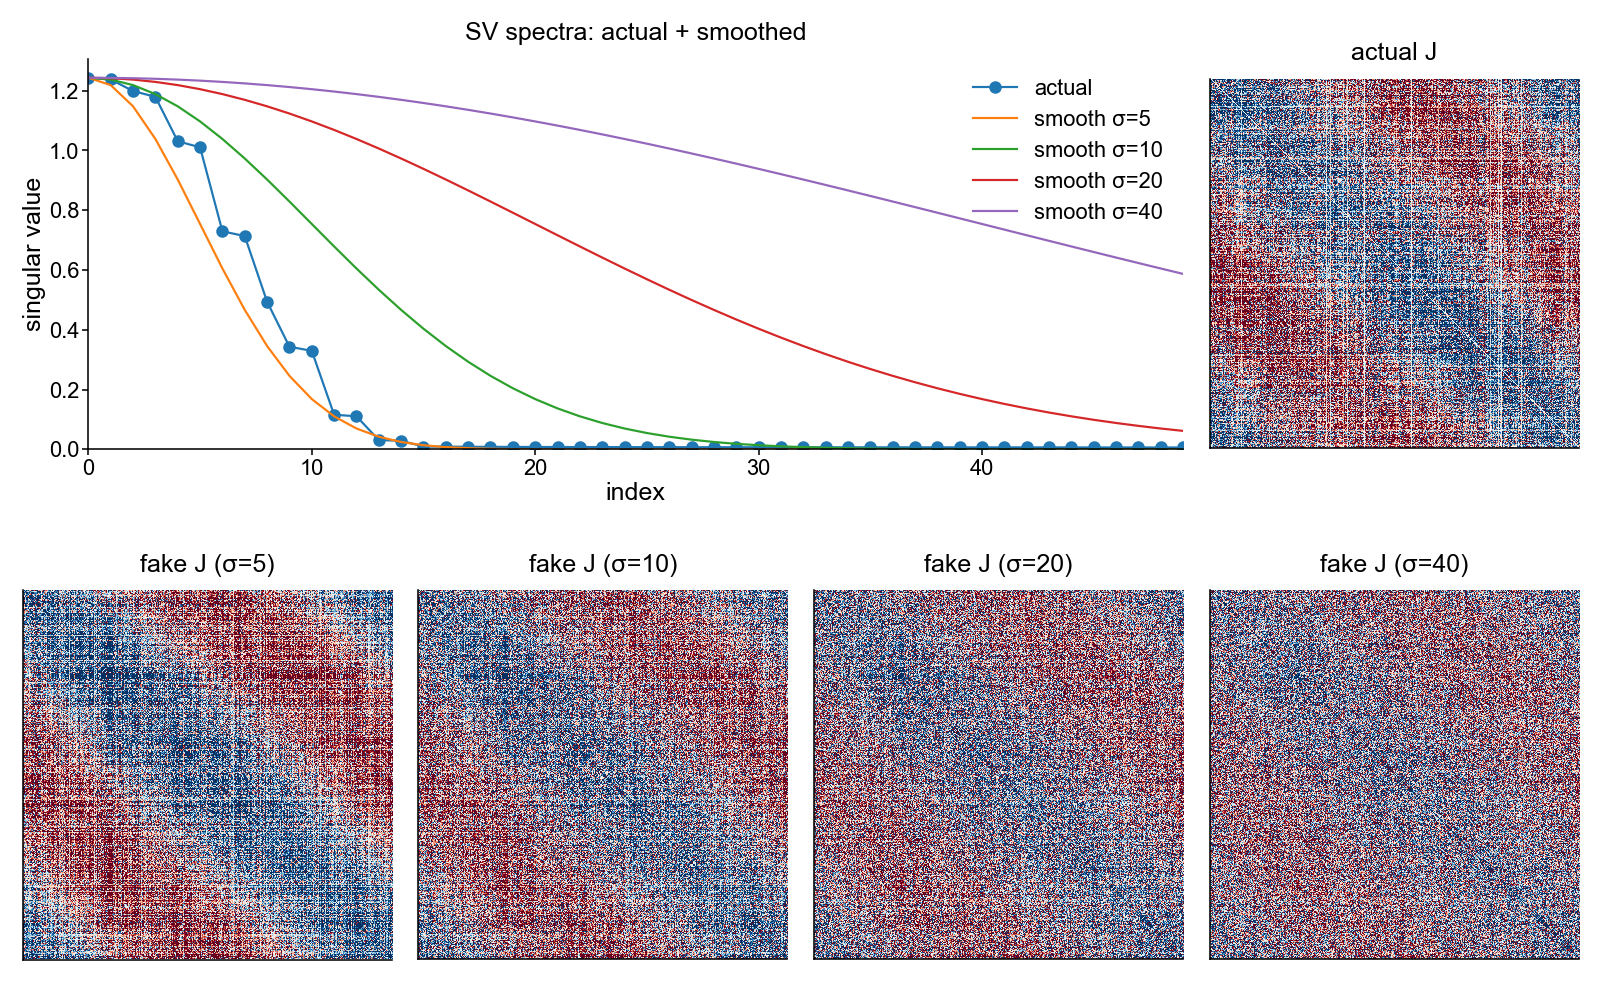

In [158]:
def imshow_weight(subfig, J_sorted, title, vscale=None, cmap=style.DIVERGING_CMAP):
    ax = subfig.subplots()
    if vscale is None:
        vscale = J_sorted.std()
    im = ax.imshow(J_sorted, vmin=-vscale, vmax=vscale, cmap=cmap,
                   interpolation='nearest', aspect=1)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
    return ax, im

def plot_spectra(subfig, s_actual, s_fakes_dict, n_show=None):
    ax = subfig.subplots()
    n = s_actual.size if n_show is None else min(n_show, s_actual.size)
    ax.plot(s_actual[:n], marker='.', color='black', label='optimal')
    # The effective rank r_eff is an ordered non-negative sweep, so color the
    # family from the 'scale' sweep ramp rather than the default cycle. This
    # keeps the family visually ordered and removes the low-contrast yellow the
    # old cycle gave the widest envelope.
    _sweep_c = style.sweep_colors(len(s_fakes_dict), 'ocean')
    for (k, s_fake), _c in zip(s_fakes_dict.items(), _sweep_c):
        ax.plot(s_fake[:n], color=_c, label=rf'$r_\mathrm{{eff}}$={k}')
    ax.set_xlim(0, n - 1)
    ax.set_ylim(0, 1.05 * s_actual[:n].max())
    ax.set_xlabel('index')
    ax.set_ylabel('singular value')
    ax.set_title('SV spectra: optimal + nulls')
    ax.legend()
    return ax

# --- figure layout ---
fig = plt.figure(figsize=(style.FULL_W, 4.5), constrained_layout=True)  # width fixed, height ~ reasonable
gs  = fig.add_gridspec(nrows=2, ncols=4)

subfig_A = fig.add_subfigure(gs[0, :3])
subfig_B = fig.add_subfigure(gs[0,  3])
subfig_C = fig.add_subfigure(gs[1,  0])
subfig_D = fig.add_subfigure(gs[1,  1])
subfig_E = fig.add_subfigure(gs[1,  2])
subfig_F = fig.add_subfigure(gs[1,  3])

# spectra
_axA = plot_spectra(subfig_A, s_actual=s, s_fakes_dict=s_fakes, n_show=50)

# One colour scale shared by all five matrices. Each panel used to be scaled to
# its own standard deviation, which silently defeated the comparison this figure
# exists to make: the r_eff=40 null really is about 2.7x the amplitude of the
# r_eff=5 one, and per-panel autoscaling hid that. max keeps every panel
# unsaturated.
_all_J = [J_real_sorted] + [J_fake_sorted[k] for k in (5, 10, 20, 40)]
_vscale = max(float(J.std()) for J in _all_J)

# actual J
_axB, _ = imshow_weight(subfig_B, J_real_sorted, title=r"$\mathbf{J}$", vscale=_vscale)

# fake Js
_axC, _ = imshow_weight(subfig_C, J_fake_sorted[5],   title=r"null $\mathbf{J}$ ($r_\mathrm{eff}$=5)", vscale=_vscale)
_axD, _ = imshow_weight(subfig_D, J_fake_sorted[10],  title=r"null $\mathbf{J}$ ($r_\mathrm{eff}$=10)", vscale=_vscale)
_axE, _ = imshow_weight(subfig_E, J_fake_sorted[20],  title=r"null $\mathbf{J}$ ($r_\mathrm{eff}$=20)", vscale=_vscale)
_axF, _ = imshow_weight(subfig_F, J_fake_sorted[40], title=r"null $\mathbf{J}$ ($r_\mathrm{eff}$=40)", vscale=_vscale)
# No colour bar. The five matrices share one scale (_vscale above), so the
# comparison the figure exists to make is carried by the panels themselves;
# absolute weight values are not the point here.

# --- panel letters (house style: 8 pt bold lowercase, via style.panel_letter) ---
# Three letters. The four nulls form one block that the caption discusses as a
# unit, so a single 'c' on the leftmost of them covers the whole bottom row.
# The spectra panel takes the house default, hanging just outside its left
# spine, because its y label and tick labels already reserve that margin.
# The matrix panels instead take x=0.0, ha='left', so the letter sits in the
# title band starting at the left spine. They carry no ticks or labels, so
# constrained_layout leaves little room outside the spine in the bottom row.
style.panel_letter(_axA, 'a')
for _ax, _s in [(_axB, 'b'), (_axC, 'c')]:
    style.panel_letter(_ax, _s, x=0.0, ha='left')

if SAVE_FIGURES:
    plt.savefig("../figures/real_vs_surrogate_matrices.png", bbox_inches='tight', dpi=400)

plt.show()




## Figure 19 — left vs. right singular vectors

Scatters consecutive pairs of left (`U`) and right (`V`) singular vectors of `J`. Both bases trace out ring geometry, which is the asymmetry the surrogate matrices above cannot reproduce. Depends on the `U`/`V` computed in the previous section. Saves `left_right_singular_vectors.png`.

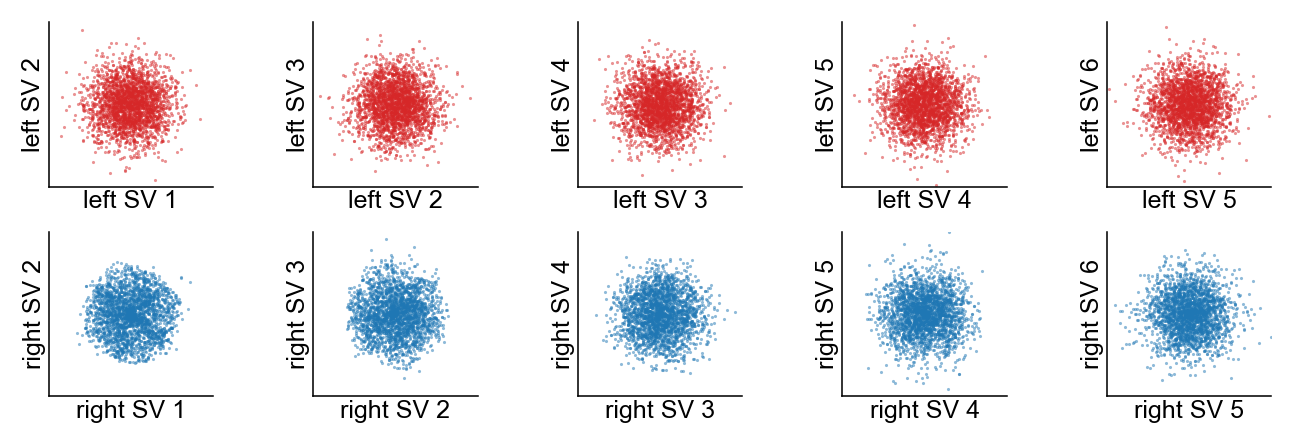

In [159]:
fig, axes = plt.subplots(2, 5, figsize=(style.FULL_W, 2.6))
for i in range(axes.shape[1]):
    ax1, ax2 = axes[:, i]
    std1, std2 = 4*U[:, i].std(), 4*V[:, i].std()
    # left vs right singular vectors are two compared CONDITIONS, so they take
    # the house pair. MAGENTA is reserved for the model-vs-circulant identity
    # in the spectra figure and must not leak anywhere else.
    ax1.scatter(U[:, i], U[:, i+1], lw=0, s=1, alpha=0.5, c=style.LINE_B)
    ax2.scatter(V[:, i], V[:, i+1], lw=0, s=1, alpha=0.5, c=style.LINE_A)
    ax1.set_xlim(-std1, std1)
    ax1.set_ylim(-std1, std1)
    ax2.set_xlim(-std2, std2)
    ax2.set_ylim(-std2, std2)

    ax1.set_xlabel(r"left SV {} of $\mathbf{{J}}$".format(i+1))
    ax1.set_ylabel(r"left SV {} of $\mathbf{{J}}$".format(i+2))

    ax2.set_xlabel(r"right SV {} of $\mathbf{{J}}$".format(i+1))
    ax2.set_ylabel(r"right SV {} of $\mathbf{{J}}$".format(i+2))

for ax in axes.flatten():
    ax.set_aspect(1.)
    ax.set_xticks([])
    ax.set_yticks([])

fig.subplots_adjust(wspace=0.5)
plt.tight_layout()

# --- panel letters (house style: 8 pt bold lowercase, via style.panel_letter) ---
# Two letters, one per row, not ten. The five columns are consecutive
# singular-vector pairs and are already indexed by their own axis labels, so a
# per-column letter would name nothing the axis labels do not. The rows are the
# units the caption refers to, left singular vectors against right. Same
# row-level convention as the eigenvector-scatter block in spectra.ipynb.
# Placed after tight_layout so the layout it computed is unchanged.
style.panel_letter(axes[0, 0], 'a')
style.panel_letter(axes[1, 0], 'b')

if SAVE_FIGURES:
    plt.savefig("../figures/left_right_singular_vectors.png", bbox_inches='tight', dpi=400)
plt.show()

## Producer (disabled): weight-noise robustness sweep → `data/ring_attractor_noise_results.npz`

Simulates the disordered and circulant networks under increasing weight noise (`f_w` = 0 → 1), tracking how the encoded angle drifts. This is the expensive cell: N=2500 over 120 time units × 34 initial conditions × 6 noise levels × 2 network types on `device=0` (requires CUDA). The `np.savez` writing the 145 MB cache is **guarded by `REGENERATE_CACHES`** (default `False`) so a re-run cannot overwrite the verified TIER-1 bit-exact baseline; set it `True` to regenerate. Seeds are set for both numpy and torch (`rng_seed=123`).

In [420]:
# NOTE: producer for ring_attractor_noise_results.npz (145 MB). The np.savez below is
# guarded by REGENERATE_CACHES (default False) so re-runs cannot overwrite the cache.
import numpy as np
import torch
import scipy
import scipy.linalg
from ring import dmft
from ring import sim
from ring import data_driven

# ----------------------------
# Params
# ----------------------------
N              = 2500
N_theta        = 500
beta           = 2.7659
scale          = 1.4211
lamda          = 1e-8
device         = 'cuda' if torch.cuda.is_available() else 'cpu'
rng_seed       = 123

# Dynamics
T_total        = 120.0
tau            = 0.050
dt             = tau / 10.0
T_eval         = 0.1
phi_fn         = lambda x: nonlin_idealized(x, beta=beta)  # defined elsewhere

# Noise levels
f_init         = 0.025
f_weights_grid = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

# Analysis times
times_of_interest = [0., 30.0, 60.0, 90.0, 120.0]

# Initial condition count
N_init         = 34

# ----------------------------
# RNG
# ----------------------------
np.random.seed(rng_seed)
torch.manual_seed(rng_seed)

# ----------------------------
# Build J and J_circ
# ----------------------------
X, Phi = gen_tuning_curves_idealized(
    N_samples=N, N_theta=N_theta, scale=scale, beta=beta
)

J, _ = data_driven.compute_weights(X=X, Phi=Phi, lamda=lamda)

J_circ_row = dmft.DMFTModel(N_theta=N, scale=scale, g=beta).J - 1
J_circ = scipy.linalg.circulant(J_circ_row)
J_circ *= (1.0 / J_circ[0, 0]) * (10.0 / N)

# ----------------------------
# Construct initial conditions
# ----------------------------
# Circular case: Gaussian bumps
n = np.arange(N)
n = np.minimum(n, N - n)
init_pattern = 4*np.exp(-(n / (0.15 * N)) ** 2) - 2

roll_amts = (np.arange(N_init) * N / N_init).round().astype(int)
x_init_circ = np.array([np.roll(init_pattern, r) for r in roll_amts]).T

# Disordered case: evenly spaced theta indices
theta_idx = (np.arange(N_init) * N_theta / N_init).round().astype(int)
x_init_dis = X[theta_idx].T


def add_noise(x_init, f):
    """Add Gaussian noise proportional to each IC’s std."""
    x_init_noisy = x_init.copy()
    for ic_idx in range(x_init.shape[1]):
        noise = np.random.randn(*x_init[:, ic_idx].shape)
        x_init_noisy[:, ic_idx] += noise * f * x_init[:, ic_idx].std()
    return x_init_noisy


x0_dis_noisy = add_noise(x_init_dis, f_init)
x0_circ_noisy = add_noise(x_init_circ, f_init)


def run_and_measure(J_base, x_init, f_weights, label):
    """Run dynamics, measure overlaps and maxima."""

    # Perturb weights
    J_noisy = J_base + np.random.randn(*J_base.shape) * f_weights * J_base.std()

    # Run simulation
    x_dyn_final, X_dyn, finished = sim.run_sim(
        T=T_total,
        tau=tau,
        dt=dt,
        T_eval=T_eval,
        J=torch.Tensor(J_noisy).to(device),
        x_init=torch.Tensor(x_init).to(device),
        nonlin=phi_fn,
        break_if_stopped=False,
    )

    # Overlap order parameter
    m_dyn = (1.0 / N) * torch.einsum(
        "ai,tib->tab",
        torch.Tensor(Phi).to(device),
        phi_fn(torch.Tensor(X_dyn).to(device)),
    ).cpu().numpy()

    # Extract times of interest
    N_t = X_dyn.shape[0]
    t_vec = np.arange(N_t) * T_eval
    toi_idx = [int(np.argmin(np.abs(t_vec - t))) for t in times_of_interest]
    m_profiles_at_t = m_dyn[toi_idx]
    x_profiles_at_t = X_dyn[toi_idx]

    # Max-angle mapping
    if label == "disordered":
        theta_max_init = np.argmax(m_dyn[0], axis=0) * 2 * np.pi / N_theta
        theta_max_t = np.argmax(m_profiles_at_t, axis=1) * 2 * np.pi / N_theta
    else:
        theta_max_init = np.argmax(X_dyn[0], axis=0) * 2 * np.pi / N
        theta_max_t = np.argmax(x_profiles_at_t, axis=1) * 2 * np.pi / N

    return dict(
        t_vec=t_vec,
        times_of_interest=times_of_interest,
        toi_idx=np.array(toi_idx, dtype=int),
        m_profiles_at_t=m_profiles_at_t,
        x_profiles_at_t=x_profiles_at_t,
        theta_max_init=theta_max_init,
        theta_max_t=theta_max_t,
        f_weights=float(f_weights),
        label=label,
    )


# ----------------------------
# Run all sweeps
# ----------------------------
results = {"disordered": {}, "circ": {}}

for f_w in f_weights_grid:
    results["disordered"][f_w] = run_and_measure(J, x0_dis_noisy, f_w, "disordered")
    results["circ"][f_w] = run_and_measure(J_circ, x0_circ_noisy, f_w, "circ")

# ----------------------------
# Save results
# ----------------------------
J_sorted = data_driven.sort_weight_matrix(J=J, Phi=Phi)[0]
if REGENERATE_CACHES:
    np.savez(
        "../data/ring_attractor_noise_results.npz",
        J_sorted=J_sorted,
        results=np.array(results, dtype=object),
        J=J.astype(np.float32),
        J_circ=J_circ.astype(np.float32),
        allow_pickle=True,
    )
    print("Saved: ring_attractor_noise_results.npz")


100%|███████████████████████████████████| 23999/23999 [00:04<00:00, 5519.59it/s]


Saved: ring_attractor_noise_results.npz


## Angle drift and activity profiles under weight noise

Reads the cache from disk and plots it; no RNG, so these panels are deterministic. This cell gives initial-vs-final encoded angle per noise level; the next gives the activity/overlap profiles for one example condition. The compose cell below assembles both, with the connectivity matrices, into `figures/noise_driven_dynamics.png`. The following cell is a side-by-side imshow of the sorted-disordered vs. circulant `J`, a diagnostic view that did not make the paper.

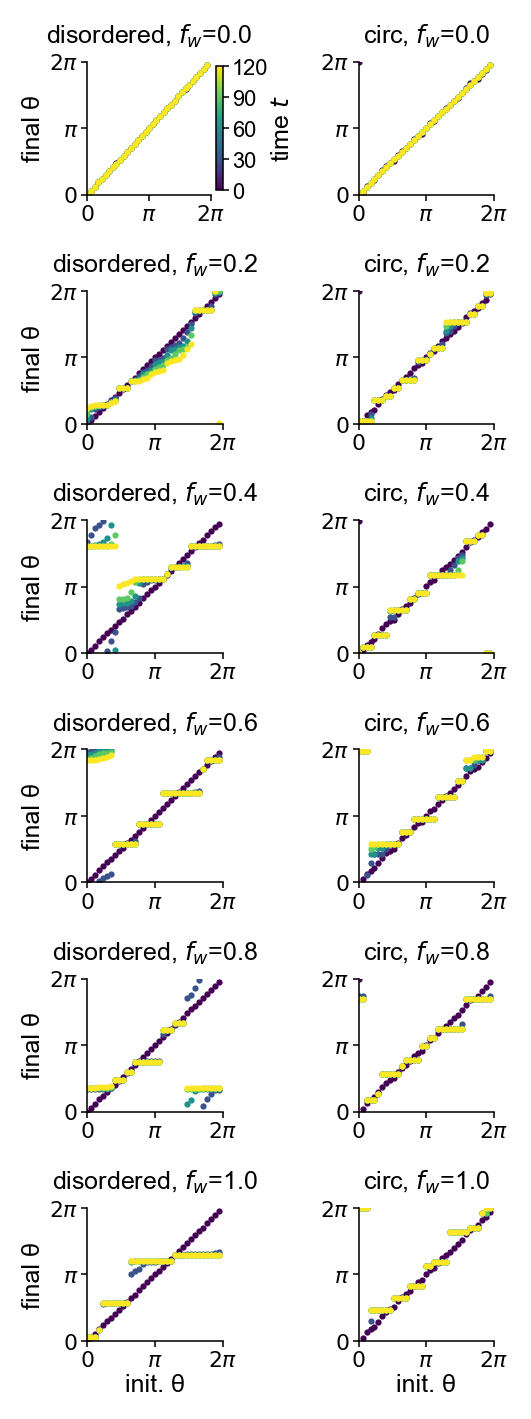

In [424]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# ----------------------------
# Load results
# ----------------------------
results_data = np.load(
    "../data/ring_attractor_noise_results.npz", "r", allow_pickle=True
)
results = results_data["results"].item()

# ----------------------------
# Globals (match analysis params)
# ----------------------------
f_weights_grid   = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]   # rows (one f_w per subplot)
times_of_interest = [0., 30.0, 60.0, 90.0, 120.0]  # colors within each subplot
N_init = 34

# Time colormap (shared across all subplots)
cmap  = style.sweep_cmap('ocean')
tnorm = mcolors.Normalize(vmin=min(times_of_interest), vmax=max(times_of_interest))


def make_plot(ax, circ_or_disordered, f_w, add_title=False, add_xlabel=False, add_ylabel=False):
    """Scatter initial theta against the theta reached at each of several times, colored by time, at fixed f_w."""
    theta = np.arange(N_init) * 2 * np.pi / N_init

    # to_show: (N_init, len(times_of_interest))
    to_show = np.array(
        [results[circ_or_disordered][f_w]["theta_max_t"][t_idx] for t_idx in range(len(times_of_interest))]
    ).T

    # Plot each time slice with time-mapped color
    for t_idx, t in enumerate(times_of_interest):
        ax.scatter(
            theta,
            to_show[:, t_idx],
            lw=0,
            s=4,
            color=cmap(tnorm(t)),
        )

    # Axes formatting (no forced aspect to preserve proportions)
    ax.set_xticks([0, np.pi, 2 * np.pi])
    ax.set_yticks([0, np.pi, 2 * np.pi])
    ax.set_xticklabels(["$0$", "$\\pi$", "$2\\pi$"])
    ax.set_yticklabels(["$0$", "$\\pi$", "$2\\pi$"])
    ax.set_xlim([0, 2 * np.pi])
    ax.set_ylim([0, 2 * np.pi])

    if add_xlabel:
        ax.set_xlabel("init. θ")
    if add_ylabel:
        ax.set_ylabel("θ at time $t$")
    if add_title:
        ax.set_title(rf"{circ_or_disordered}, $\alpha_\mathrm{{noise}}$={f_w}")


# ----------------------------
# Make figure
# Rows = f_w levels, Cols = (disordered, circ)
# ----------------------------
fig, axes = plt.subplots(len(f_weights_grid), 2, figsize=(2.4, 6.35))
fig.subplots_adjust(wspace=0.025)

for r, f_w in enumerate(f_weights_grid):
    # Left column: disordered
    make_plot(
        axes[r, 0],
        "disordered",
        f_w,
        add_title=True,                          # show f_w + condition
        add_xlabel=(r == len(f_weights_grid) - 1),  # only bottom row
        add_ylabel=True                           # only left column
    )
    # Right column: circ
    make_plot(
        axes[r, 1],
        "circ",
        f_w,
        add_title=True,
        add_xlabel=(r == len(f_weights_grid) - 1),
        add_ylabel=False
    )

# Single colorbar for time on the upper-left plot
sm = cm.ScalarMappable(norm=tnorm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[0, 0], fraction=0.046, pad=0.04)
cbar.set_label("time $t$")
cbar.set_ticks(times_of_interest)

plt.tight_layout()

plt.show()


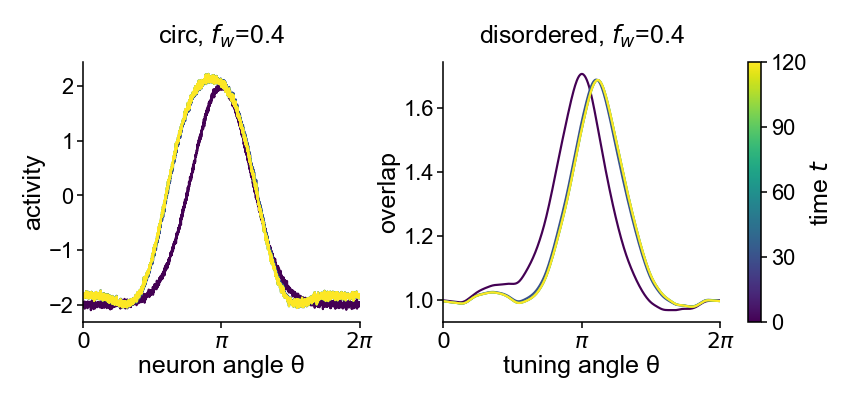

In [425]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# ----------------------------
# Globals
# ----------------------------
times_of_interest = [0., 30., 60., 90., 120.]
cmap  = style.sweep_cmap('ocean')
tnorm = mcolors.Normalize(vmin=min(times_of_interest), vmax=max(times_of_interest))

# Pick example IC
ic_idx = 17
f_w = 0.4

# Extract profiles
x_profiles = results["circ"][f_w]["x_profiles_at_t"][:, :, ic_idx]       # (len(times), N)
m_profiles = results["disordered"][f_w]["m_profiles_at_t"][:, :, ic_idx] # (len(times), N_theta)

N = x_profiles.shape[1]
N_theta = m_profiles.shape[1]

x_vals_circ = np.arange(N) * 2*np.pi / N
x_vals_dis  = np.arange(N_theta) * 2*np.pi / N_theta

# ----------------------------
# Make figure
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(4, 1.5))
ax1, ax2 = axes

# Circular case
for t_idx, t in enumerate(times_of_interest):
    ax1.plot(
        x_vals_circ,
        x_profiles[t_idx],
        color=cmap(tnorm(t)),
    )
ax1.set_title(r"circ, $\alpha_\mathrm{noise}$=0.4")
ax1.set_xlabel("neuron angle θ")
ax1.set_ylabel("activity")
ax1.set_xticks([0, np.pi, 2*np.pi])
ax1.set_xticklabels(["$0$", "$\\pi$", "$2\\pi$"])

# Disordered case
for t_idx, t in enumerate(times_of_interest):
    ax2.plot(
        x_vals_dis,
        m_profiles[t_idx],
        color=cmap(tnorm(t)),
    )
ax2.set_title(r"disordered, $\alpha_\mathrm{noise}$=0.4")
ax2.set_xlabel("tuning angle θ")
ax2.set_ylabel("overlap")
ax2.set_xticks([0, np.pi, 2*np.pi])
ax2.set_xticklabels(["$0$", "$\\pi$", "$2\\pi$"])

fig.subplots_adjust(wspace=0.3)


# Shared colorbar for time
sm = cm.ScalarMappable(norm=tnorm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, fraction=0.046, pad=0.04)
cbar.set_label("time $t$")
cbar.set_ticks(times_of_interest)
for ax in axes:
    ax.set_xlim(0, 2*np.pi)
    

plt.show()


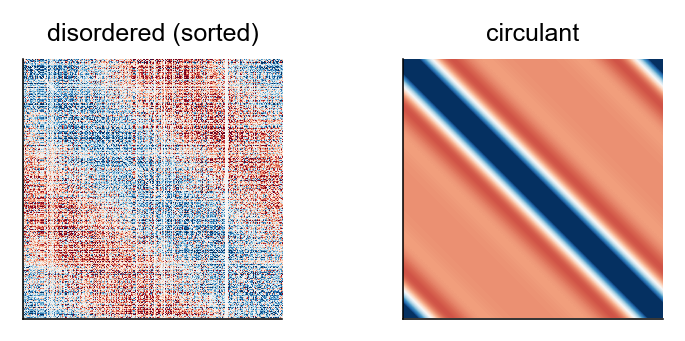

In [427]:
fig, axes = plt.subplots(1, 2, figsize=(4, 1.5))
ax1, ax2 = axes
ax1.imshow(results_data['J_sorted'], vmin=-0.0025, vmax=0.0025, cmap=style.DIVERGING_CMAP)
ax2.imshow(results_data['J_circ'], vmin=-0.0025, vmax=0.0025, cmap=style.DIVERGING_CMAP)
for ax in axes:
    ax.set_aspect(1.)
    ax.set_xticks([])
    ax.set_yticks([])
ax1.set_title("disordered (sorted)")
ax2.set_title("circulant")


plt.show()

In [ ]:
"""
Compose the noise-driven-dynamics figure in full, so every panel is
reproducible from code. Nothing new is computed here:
each panel re-draws the exact content of the legacy single-panel cells above,
only the arrangement changes.
  A  connectivity matrices, disordered (sorted) | circulant        [cell above, imshow]
  B  drift profiles at f_w=0.4, disordered/overlap | circ/activity [drift-trajectories cell, columns swapped so disordered reads left, matching the composite]
  C  angular-stability scatter grid, 6 f_w levels x (disordered|circ), reusing make_plot [angular-stability cell]
Relies on state built by running the notebook top to bottom: results,
results_data, make_plot, f_weights_grid, times_of_interest, cmap, tnorm.
Layout: left column stacks A over B (top-aligned); right third is the full-height
C grid with its shared time colorbar attached to the top-left subplot.
The two Panel-B drift arrows are drawn in data coordinates.
"""

import matplotlib.cm as cm
from matplotlib.gridspec import GridSpecFromSubplotSpec

FIG_W, FIG_H = style.FULL_W, style.FULL_W * 8.1 / 10.0
fig = plt.figure(figsize=(FIG_W, FIG_H))

outer = fig.add_gridspec(
    1, 2, width_ratios=[1.9, 1.0], wspace=0.16,
    left=0.05, right=0.97, top=0.95, bottom=0.05,
)

# ---- Left column: A over B (top-aligned, whitespace below) ----
gsL = GridSpecFromSubplotSpec(
    3, 1, subplot_spec=outer[0, 0],
    height_ratios=[1.0, 0.78, 0.5], hspace=0.5,
)

# --- Panel A: two connectivity matrices ---
gsA = GridSpecFromSubplotSpec(1, 2, subplot_spec=gsL[0], wspace=0.15)
axA1 = fig.add_subplot(gsA[0])
axA2 = fig.add_subplot(gsA[1])
axA1.imshow(results_data["J_sorted"], vmin=-0.0025, vmax=0.0025, cmap=style.DIVERGING_CMAP)
axA2.imshow(results_data["J_circ"], vmin=-0.0025, vmax=0.0025, cmap=style.DIVERGING_CMAP)
for ax in (axA1, axA2):
    ax.set_aspect(1.0)
    ax.set_xticks([])
    ax.set_yticks([])
axA1.set_title("disordered (sorted)")
axA2.set_title("circulant")

# --- Panel B: drift profiles (disordered LEFT, circ RIGHT) + shared time colorbar ---
gsB = GridSpecFromSubplotSpec(1, 2, subplot_spec=gsL[1], wspace=0.42)
axB1 = fig.add_subplot(gsB[0])  # disordered / overlap
axB2 = fig.add_subplot(gsB[1])  # circ / activity

ic_idx = 17
f_w_B = 0.4
x_profiles = results["circ"][f_w_B]["x_profiles_at_t"][:, :, ic_idx]        # (times, N)
m_profiles = results["disordered"][f_w_B]["m_profiles_at_t"][:, :, ic_idx]  # (times, N_theta)
N_B = x_profiles.shape[1]
N_theta_B = m_profiles.shape[1]
x_vals_circ = np.arange(N_B) * 2 * np.pi / N_B
x_vals_dis = np.arange(N_theta_B) * 2 * np.pi / N_theta_B

for t_idx, t in enumerate(times_of_interest):
    axB1.plot(x_vals_dis, m_profiles[t_idx], color=cmap(tnorm(t)))
axB1.set_title(r"disordered, $\alpha_\mathrm{noise}$=0.4")
axB1.set_xlabel("tuning angle θ")
axB1.set_ylabel("overlap")

for t_idx, t in enumerate(times_of_interest):
    axB2.plot(x_vals_circ, x_profiles[t_idx], color=cmap(tnorm(t)))
axB2.set_title(r"circ, $\alpha_\mathrm{noise}$=0.4")
axB2.set_xlabel("neuron angle θ")
axB2.set_ylabel("activity")

for ax in (axB1, axB2):
    ax.set_xticks([0, np.pi, 2 * np.pi])
    ax.set_xticklabels(["$0$", "$\\pi$", "$2\\pi$"])
    ax.set_xlim(0, 2 * np.pi)

# --- drift-direction arrows ---
_drift_arrow = dict(facecolor="black", edgecolor="black", width=1.6,
                    headwidth=8, headlength=8, shrink=0)
axB1.annotate("", xy=(1.02 * np.pi, 1.52), xytext=(0.78 * np.pi, 1.62),
              arrowprops=_drift_arrow)  # disordered overlap peak drifts right
axB2.annotate("", xy=(0.60 * np.pi, 1.45), xytext=(0.86 * np.pi, 0.90),
              arrowprops=_drift_arrow)  # circ activity bump drifts left

smB = cm.ScalarMappable(norm=tnorm, cmap=cmap)
smB.set_array([])
cbarB = style.add_colorbar(fig, smB, [axB1, axB2],
                           ticks=times_of_interest, label="time $t$")

# ---- Right column: Panel C, 6x2 scatter grid + colorbar on top-left ----
gsC = GridSpecFromSubplotSpec(
    len(f_weights_grid), 2, subplot_spec=outer[0, 1],
    hspace=0.55, wspace=0.3,
)
axC = np.empty((len(f_weights_grid), 2), dtype=object)
for r in range(len(f_weights_grid)):
    for c in range(2):
        axC[r, c] = fig.add_subplot(gsC[r, c])
for r, f_w in enumerate(f_weights_grid):
    make_plot(axC[r, 0], "disordered", f_w, add_title=True,
              add_xlabel=(r == len(f_weights_grid) - 1), add_ylabel=True)
    make_plot(axC[r, 1], "circ", f_w, add_title=True,
              add_xlabel=(r == len(f_weights_grid) - 1), add_ylabel=False)

smC = cm.ScalarMappable(norm=tnorm, cmap=cmap)
smC.set_array([])
# Inset the Panel-C time colorbar into the empty upper-left triangle of the
# f_w=0 subplot. Attaching it to the axis (shrink mode) stole inter-column
# width and collided with the adjacent column's 2pi tick; an inset keeps the
# bar inside Panel C without intruding. Sized with the house colorbar thickness.
caxC = axC[0, 0].inset_axes([0.13, 0.48, 0.055, 0.44])
cbarC = fig.colorbar(smC, cax=caxC, ticks=times_of_interest, label="time $t$")
cbarC.outline.set_linewidth(0.5)

# ---- panel letters ----
LETTER_KW = dict(fontsize=8, fontweight="bold", va="bottom", ha="right")
axA1.text(-0.14, 1.05, "a", transform=axA1.transAxes, **LETTER_KW)
axB1.text(-0.30, 1.08, "b", transform=axB1.transAxes, **LETTER_KW)
axC[0, 0].text(-0.55, 1.18, "c", transform=axC[0, 0].transAxes, **LETTER_KW)

if SAVE_FIGURES:
    plt.savefig("../figures/noise_driven_dynamics.png", bbox_inches="tight", dpi=400)

plt.show()


## Subsample spectrum — convergence with population size

Recomputes eigenvalues and singular-vector modes for progressively larger recorded populations (N = 100 → 1533, the last matching the Peyrache dataset). The published composite, `figures/data_and_subsample_spectra.png`, is assembled in `data_driven_reconstruction.ipynb`, which hosts its own copy of this computation; this cell is the standalone version.

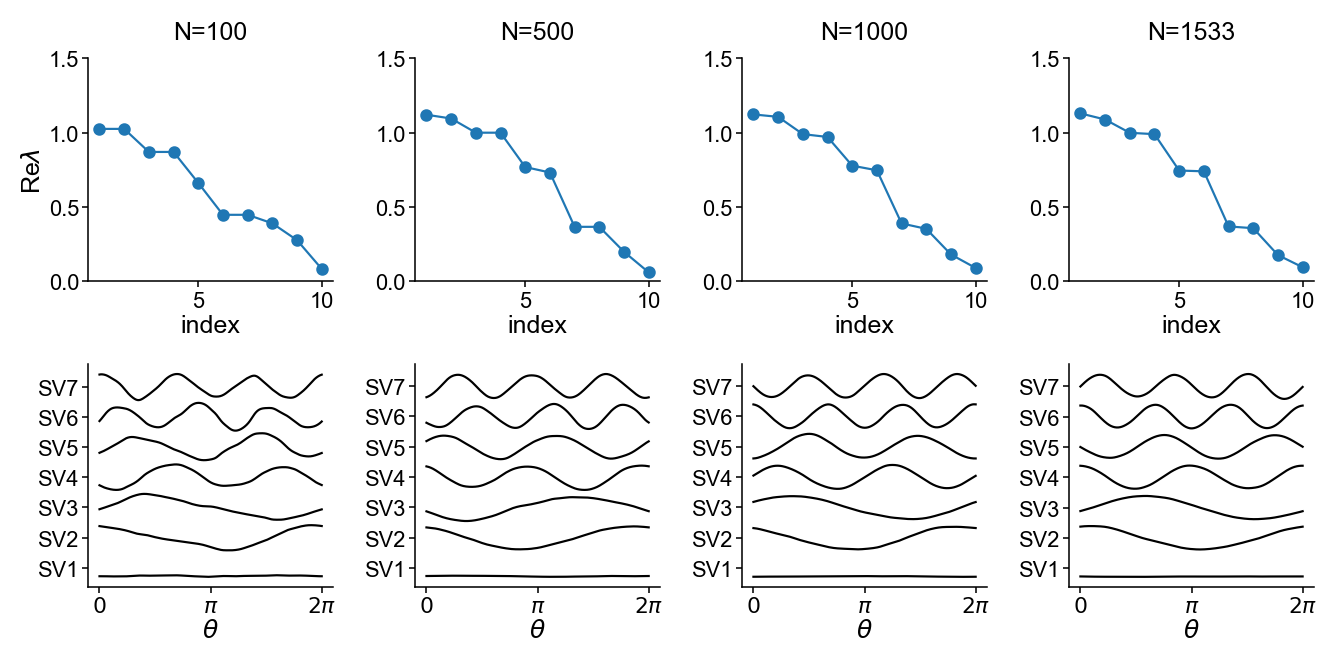

In [32]:
N_values = [100, 500, 1000, 1533]
fig, axes = plt.subplots(2, 4, figsize=(6, 3))

for col, N_data in enumerate(N_values):
    X, Phi = gen_tuning_curves_idealized(N_samples=N_data, N_theta=N_theta,
                                         scale=scale, beta=beta)
    J, J_uc = data_driven.compute_weights(X=X, Phi=Phi, lamda=lamda)
    w = np.linalg.eigvals(J)
    U, s, Vt = np.linalg.svd(Phi)
    
    # Top row: eigenvalues
    ax_eig = axes[0, col]
    ax_eig.plot(np.arange(10)+1, w.real[np.argsort(w.real)[::-1]][:10], marker='.', clip_on=False)
    ax_eig.set_title(f'N={N_data}')
    if col == 0:
        ax_eig.set_ylabel('Re$\\lambda$')
    ax_eig.set_ylim(0, 1.5)
    ax_eig.set_xlabel("index")
    
    # Bottom row: SVs
    ax_sv = axes[1, col]
    colors = ['red', 'green', 'orange', 'brown', 'gray', 'black', 'salmon']
    for i in range(7):
        mode = U[:, i]
        normalized_mode = 6 * mode / np.sqrt((mode**2).sum())
        ax_sv.plot(np.arange(len(U))*2*np.pi/len(U), normalized_mode + i, color='black')
    ax_sv.set_yticks(np.arange(7))
    ax_sv.set_yticklabels(['SV'+str(i+1) for i in range(7)])
    ax_sv.set_xticks([0, np.pi, 2*np.pi])
    ax_sv.set_xticklabels(["$0$", "$\\pi$", "$2\\pi$"])
    ax_sv.set_xlabel("$\\theta$")

plt.tight_layout()
plt.show()

## Exploratory: alignment of the left and right singular bases (not in paper)

Recomputes `J` and inspects the overlap between its left and right singular vectors. No paper output.

In [41]:
N        = 2500
N_theta  = 500
beta     = 2.7659
scale    = 1.4211
lamda    = 1e-8

X, Phi = gen_tuning_curves_idealized(N_samples=N, N_theta=N_theta,
                                     scale=scale, beta=beta)
J, J_uc = data_driven.compute_weights(X=X, Phi=Phi, lamda=lamda)
U, s, Vt = np.linalg.svd(J, full_matrices=False)
V = Vt.T

Vx = U
Vphi = V



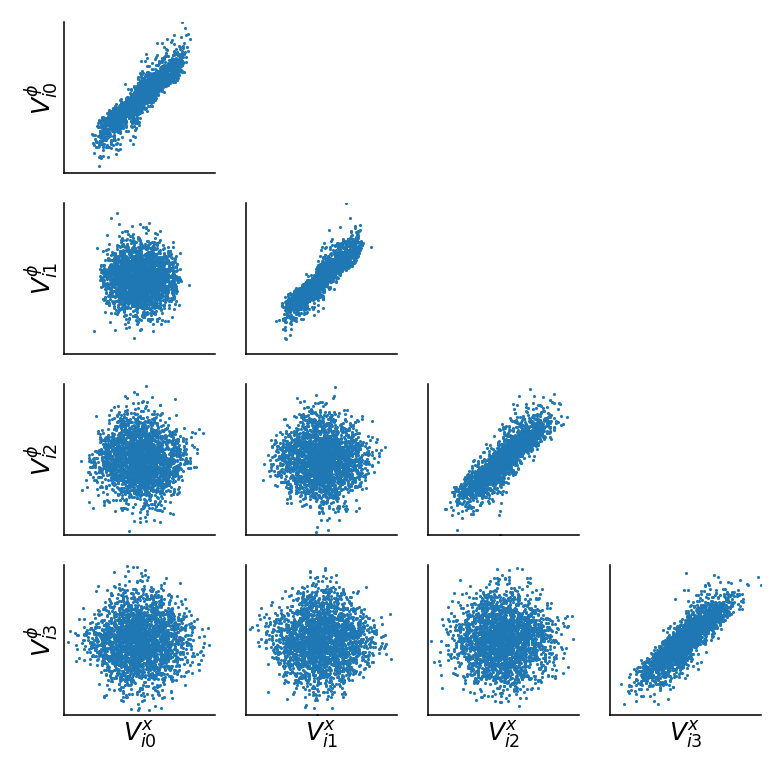

In [59]:
fig, axes = plt.subplots(4, 4, figsize=(4, 4))
for i in range(4):
    for j in range(4):
        ax = axes[i,j]
        if i >= j:
            ax.scatter(Vphi[:, i], Vx[:, j], lw=0, s=1)
            v = np.max(np.abs(np.concatenate((Vx[:, i], Vphi[:, j]))))
            ax.set_xlim(-v, v)
            ax.set_ylim(-v, v)
            ax.set_aspect(1.)
        else:
            ax.set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])
        if i == 3:
            ax.set_xlabel("$V^x_{i"+str(j)+"}$")
        if j == 0:
            ax.set_ylabel("$V^\\phi_{i"+str(i)+"}$")

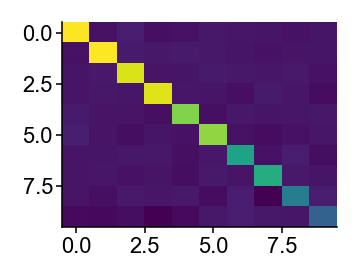

In [40]:
plt.imshow((Vphi.T @ Vx)[:10, :10])

## Figure 11 — low-rank comparison model

A rank-4 Gaussian random matrix `J = (1/N) M Mᵀ` with two 2D subspaces of unequal variance, run under `tanh` dynamics from initial conditions in each subspace. Projecting onto the κ coordinates shows which subspace supports a continuous attractor. The `np.random.seed(42)` before `M` is fix F4 — the figure is illustrative rather than data-derived, so the seed exists purely to pin the realization. The next cell plots and saves `low_rank_connectivity.pdf`.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Setup
N = 10000
D = 2
np.random.seed(42)
M = np.random.randn(N, 2*D)
M *= np.repeat(np.array([10., 5.]), 2)[None, :]
J = (1./N) * (M @ M.T)
N_init = 40

dt = 0.1
T = 10
N_t = int(T / dt)

# Symmetric initialization, shared with the mixture network below so the two
# figures are directly comparable: every initial condition carries an
# independent uniform angle in BOTH doublets at equal amplitude. One simulation
# suffices, since there is no longer an "initialized doublet" to vary. This also
# stops the escape from the subdominant ring depending on a finite-N residual to
# seed it, because that ring is no longer where we start.
# Evenly spaced angles, permuted independently per doublet: full, even coverage
# of both rings, while the two circular coordinates stay independent. Uniform
# random draws leave visible gaps at N_init = 40.
r0 = 5.
_even = np.arange(N_init) * 2*np.pi / N_init
angle0 = np.stack([_even, np.random.permutation(_even)])
subspaces = [M[:, 2*d:2*d+2] / np.std(M[:, 2*d:2*d+2], axis=0) for d in range(D)]
init_pts = sum(r0 * subspaces[d] @ np.array([np.cos(angle0[d]), np.sin(angle0[d])])
               for d in range(D))

X = np.zeros((N_t, N, N_init))
X[0] = init_pts
for i in range(1, N_t):
    X[i] = (1-dt)*X[i-1] + dt*(J @ np.tanh(X[i-1]))

# kappa per doublet, in units of the loading standard deviation
all_kappas = [(1./N) * np.einsum('ik,tib->tkb', M[:, 2*d:2*d+2], np.tanh(X))
              * (1/np.std(M[:, 2*d:2*d+2], axis=0))[None, :, None] for d in range(D)]

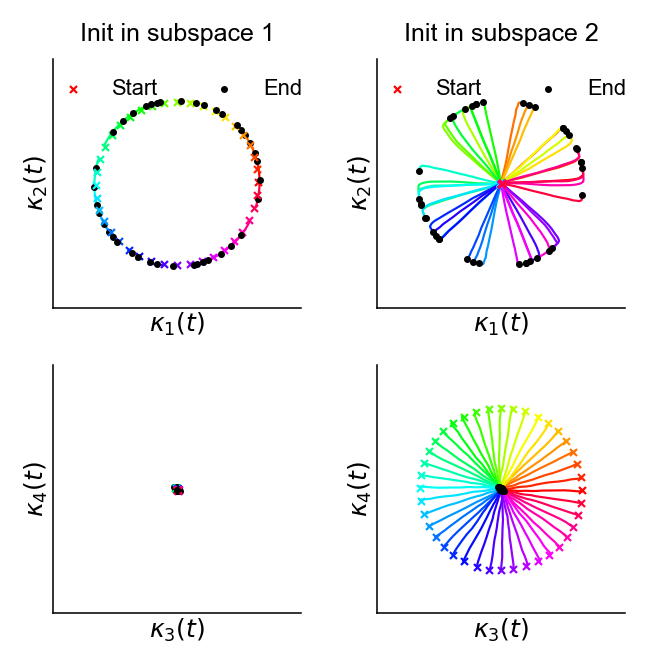

In [221]:

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(style.FULL_W, 2.4))
cmap = style.ANGLE_CMAP

# One limit shared by both panels, from the data, so the two doublets are drawn
# on the same scale and fill their axes.
_lim = 1.25 * max(np.abs(k).max() for k in all_kappas)

def plot_trajectories(ax, kappas, ang, xlabel, ylabel, show_legend=False):
    """Trajectories in one doublet, colored by their initial angle in that same
    doublet, so each panel is readable on its own terms."""
    for ic_idx in range(N_init):
        kap = kappas[:, :, ic_idx]
        color = cmap((ang[ic_idx] % (2*np.pi)) / (2*np.pi))
        ax.plot(kap[:, 0], kap[:, 1], color=color)
        lbl = dict(label='Start') if (ic_idx == 0 and show_legend) else {}
        ax.scatter(kap[0, 0], kap[0, 1], marker='x', s=5, c=[color], zorder=10000, **lbl)
        lbl = dict(label='End') if (ic_idx == 0 and show_legend) else {}
        ax.scatter(kap[-1, 0], kap[-1, 1], lw=0, s=5, c='black', zorder=10000, **lbl)
    ax.set_xlim(-_lim, _lim)
    ax.set_ylim(-_lim, _lim)
    ax.set_aspect(1.)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if show_legend:
        ax.legend(loc='upper center', ncol=2)

plot_trajectories(axes[0], all_kappas[0], angle0[0],
                  r'$\kappa_1(t)$', r'$\kappa_2(t)$', show_legend=True)
plot_trajectories(axes[1], all_kappas[1], angle0[1],
                  r'$\kappa_3(t)$', r'$\kappa_4(t)$')

axes[0].set_title('Dominant doublet')
axes[1].set_title('Subdominant doublet')

# --- panel letters (house style: 8 pt bold lowercase, via style.panel_letter) ---
# Two panels, two letters: one projection per doublet, from a single simulation.
for _ax, _s in zip(axes, 'ab'):
    style.panel_letter(_ax, _s)

fig.subplots_adjust(left=0.30, right=0.70, top=0.88, bottom=0.08, wspace=0.15)
if SAVE_FIGURES:
    plt.savefig("../figures/low_rank_connectivity.pdf")
plt.show()

## Mixture-loading comparison model — `low_rank_mixture_torus.pdf`

The counterexample companion to the rank-four Gaussian network above. The loadings are drawn from a
mixture of $D$ Gaussians, the $d$-th of which is supported on doublet $d$ alone, with component
variance $D \sigma_d^2$ so that $\langle \bm{u}\bm{u}^T \rangle$, and therefore the whole weight
spectrum, is *identical* to the Gaussian model's. The symmetry group is the same $(SO(2))^D$ as
well. What changes is that each neuron now loads onto a single doublet, so the doublets no longer
share a gain: they decouple, every ring is stable at once, and the attractor is the full torus
rather than the union of rings. `np.random.seed(42)` matches the Gaussian cell above; the figure is
illustrative rather than data-derived, so the seed exists purely to pin the realization.

Initial conditions carry independent uniform random angles in *both* doublets, with a large amplitude in one and a small seed in the other. Because the doublets decouple, each one keeps its own initial angle and grows to its own ring, so a full ring of final states appears in both planes whichever doublet was initialized.

In [ ]:
# Rank-2D mixture-loading network. Distinct names (suffix `_mix`) so the Gaussian
# model built above stays intact for anything downstream.
N_mix = 10000
D_mix = 2
doublet_std = np.array([10., 5.])              # per-doublet loading std, as in the Gaussian model
comp_std = np.sqrt(D_mix) * doublet_std        # mixture components, chosen to match <u u^T> exactly

np.random.seed(42)
group = np.random.randint(0, D_mix, size=N_mix)   # which doublet each neuron loads onto
z_mix = np.random.randn(N_mix, 2)
M_mix = np.zeros((N_mix, 2 * D_mix))
for d in range(D_mix):
    M_mix[group == d, 2 * d:2 * d + 2] = comp_std[d] * z_mix[group == d]
J_mix = (1. / N_mix) * (M_mix @ M_mix.T)

# Empirical loading std per doublet; kappa is reported in these units, as in the Gaussian figure.
std_mix = np.array([np.std(M_mix[:, 2 * d:2 * d + 2]) for d in range(D_mix)])
scale_mix = np.repeat(std_mix, 2)

N_init_mix = 40
dt_mix = 0.1
T_mix = 10
N_t_mix = int(T_mix / dt_mix)

# Same symmetric protocol as the Gaussian network above: equal amplitude in both
# doublets, evenly spaced angles permuted independently per doublet, one
# simulation. The two figures are then directly comparable, and any difference
# in outcome is a property of the loading distribution alone.
r0_mix = 0.45
_even_mix = np.arange(N_init_mix) * 2 * np.pi / N_init_mix
angle0_mix = np.stack([_even_mix, np.random.permutation(_even_mix)])

kap0 = np.zeros((2 * D_mix, N_init_mix))
for d in range(D_mix):
    kap0[2 * d] = r0_mix * np.cos(angle0_mix[d])
    kap0[2 * d + 1] = r0_mix * np.sin(angle0_mix[d])
X_mix = (M_mix / scale_mix[None, :]) @ kap0

traj = np.zeros((N_t_mix, 2 * D_mix, N_init_mix))
for i in range(N_t_mix):
    P_mix = np.tanh(X_mix)
    traj[i] = (1. / N_mix) * (M_mix.T @ P_mix) / scale_mix[:, None]
    X_mix = (1 - dt_mix) * X_mix + dt_mix * (J_mix @ P_mix)
all_kappas_mix = [traj[:, 2 * d:2 * d + 2, :] for d in range(D_mix)]

# Mean-field check: the doublets decouple, so each ring radius solves
# sigma_d^2 <phi'> = 1 independently, with <phi'> taken at variance (D sigma_d^2) |kappa_d|^2.
_z = np.linspace(-30., 30., 200001)
def _E_phi_prime(q):
    w = np.exp(-_z ** 2 / (2 * q)) / np.sqrt(2 * np.pi * q)
    return np.trapz((1. - np.tanh(_z) ** 2) * w, _z)

def _solve_q(target):
    lo, hi = 0., 1.
    while _E_phi_prime(hi) > target:
        hi *= 2
    for _ in range(200):
        mid = .5 * (lo + hi)
        lo, hi = (mid, hi) if _E_phi_prime(mid) > target else (lo, mid)
    return .5 * (lo + hi)

pred_radius = np.array([np.sqrt(_solve_q(1. / sd ** 2)) / (np.sqrt(D_mix) * sd ** 2)
                        for sd in doublet_std])
print("predicted ring radii (normalized kappa):", np.round(pred_radius, 4))
for d in range(D_mix):
    fin = all_kappas_mix[d][-1]
    r = np.linalg.norm(fin, axis=0)
    drift = np.angle(np.exp(1j * (np.arctan2(fin[1], fin[0]) - angle0_mix[d])))
    print(f"  doublet {d + 1}: radius {r.mean():.4f} +/- {r.std():.4f}, "
          f"|angle drift| <= {np.abs(drift).max():.4f} rad")


In [ ]:

# Plotting, mirroring the Gaussian figure above panel for panel.
fig, axes = plt.subplots(1, 2, figsize=(style.FULL_W, 2.4))
cmap = style.ANGLE_CMAP

_lim_mix = 1.25 * max(np.abs(k).max() for k in all_kappas_mix)

def plot_trajectories_mix(ax, kappas, ang, xlabel, ylabel, show_legend=False):
    for ic_idx in range(N_init_mix):
        kap = kappas[:, :, ic_idx]
        color = cmap((ang[ic_idx] % (2*np.pi)) / (2*np.pi))
        ax.plot(kap[:, 0], kap[:, 1], color=color)
        lbl = dict(label='Start') if (ic_idx == 0 and show_legend) else {}
        ax.scatter(kap[0, 0], kap[0, 1], marker='x', s=5, c=[color], zorder=10000, **lbl)
        lbl = dict(label='End') if (ic_idx == 0 and show_legend) else {}
        ax.scatter(kap[-1, 0], kap[-1, 1], lw=0, s=5, c='black', zorder=10000, **lbl)
    ax.set_xlim(-_lim_mix, _lim_mix)
    ax.set_ylim(-_lim_mix, _lim_mix)
    ax.set_aspect(1.)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if show_legend:
        ax.legend(loc='upper center', ncol=2)

plot_trajectories_mix(axes[0], all_kappas_mix[0], angle0_mix[0],
                      r'$\kappa_1(t)$', r'$\kappa_2(t)$', show_legend=True)
plot_trajectories_mix(axes[1], all_kappas_mix[1], angle0_mix[1],
                      r'$\kappa_3(t)$', r'$\kappa_4(t)$')

axes[0].set_title('Dominant doublet')
axes[1].set_title('Subdominant doublet')

# --- panel letters (house style: 8 pt bold lowercase, via style.panel_letter) ---
# Two panels, two letters, matching the Gaussian figure above.
for _ax, _s in zip(axes, 'ab'):
    style.panel_letter(_ax, _s)

fig.subplots_adjust(left=0.30, right=0.70, top=0.88, bottom=0.08, wspace=0.15)
if SAVE_FIGURES:
    plt.savefig("../figures/low_rank_mixture_torus.pdf")
plt.show()

## Additional figure — spectrum vs. theory at N = 1533

Overlay of the optimal weight matrix's eigenvalues with the theoretical prediction $\alpha\,\lambda^x_n/\lambda^\phi_n$ for the generative-process network at $N = N_{\text{data}} = 1533$; not a numbered figure in the paper. Seeded for reproducibility. Writes `../figures/weight_spectrum_vs_theory.png`.

In [ ]:
np.random.seed(42)  # original was unseeded; fixed for reproducibility
N_data = 1533
X, Phi = gen_tuning_curves_idealized(N_samples=N_data, N_theta=N_theta, scale=scale, beta=beta)
J, J_uc = data_driven.compute_weights(X=X, Phi=Phi, lamda=lamda)
w = np.linalg.eigvals(J)

# Theoretical prediction: alpha * lambda^x_n / lambda^phi_n
Gamma_x = X @ X.T / X.shape[1]
Gamma_phi = Phi @ Phi.T / Phi.shape[1]
eig_x = np.sort(np.linalg.eigvalsh(Gamma_x))[::-1]
eig_phi = np.sort(np.linalg.eigvalsh(Gamma_phi))[::-1]
alpha = nonlin_idealized_deriv_avg(X, beta)
prediction = np.sort(alpha * eig_x[:10] / eig_phi[:10])[::-1]

fig = plt.figure(figsize=(style.FULL_W, 2.2))
fig.add_axes([0.34, 0.20, 0.32, 0.68])  # centered narrow axis, whitespace-padded to FULL_W
plt.plot(np.arange(10)+1, np.sort(w.real)[::-1][:10], 'o-', ms=4, label='$J$ eigenvalues')
plt.plot(np.arange(10)+1, prediction, 'x--', ms=4, color=style.MODEL, label='$\\alpha \\lambda^x_n / \\lambda^\\phi_n$')
plt.xlabel('index')
plt.ylabel('Re $\\lambda$')
plt.legend()
plt.title(f'N={N_data}')
if SAVE_FIGURES:
    plt.savefig("../figures/weight_spectrum_vs_theory.png", dpi=400)
plt.show()

## Fisher-Lee circular correlation between the SVD angle and the tuning-curve center of mass

The supplement quotes the Fisher-Lee circular correlation between the SVD-derived angular coordinate $\theta_i^\text{SVD}$ and the tuning-curve center of mass $\theta_i^\text{COM}$, as evidence that the leading singular-vector doublet carries tuning information. Recipe recovered from the pre-cleanup `paper_new_analyses.ipynb` (commit `0d71804`, cell 3), which produced `0.6943` from one unseeded draw at the pre-rescale `lamda = 1e-6`.

Two things determine how the number should be quoted.

The **sign is arbitrary**, because LAPACK fixes singular-vector signs per realization, so the SVD angle can wind either way around the ring. Only $|r|$ is meaningful.

The **magnitude needs $N$ larger than the $N = 2500$ used in the figures**. The first two doublets of $J$ are close, and at finite $N$ each doublet is split by sampling noise of order $1/\sqrt{N}$. At $N = 2500$ that splitting (mean 0.017) is within a factor of two of the gap between doublets (mean 0.030), so the two occasionally cross, the leading singular pair straddles both doublets, and $|r|$ collapses (1 seed in 10, down to 0.10). At $N = 5000$ the splitting falls to 0.012 while the gap holds at 0.034, and no seed collapses. This cell therefore reports the range over ten seeds at $N = 5000$.

In [3]:
# Fisher-Lee circular correlation between theta^SVD and theta^COM for the
# generative-process network (Setting 3). Self-contained: the cells above overwrite
# X, Phi, J and U, so everything is rebuilt here. Writes no figure and no cache.
#
# NOTE: astropy.stats.circcorrcoef is the Jammalamadaka-Sarma circular correlation, a
# DIFFERENT statistic, and it returns about 0.21 on this same data. A reader re-deriving
# the number with that library call gets a threefold disagreement that is a difference of
# definition and not an error in the values below.
from ring import analysis, seed as ring_seed

def circular_correlation(alpha, beta_ang):
    """Fisher-Lee circular correlation between two angle arrays (in radians)."""
    sin_a = np.sin(alpha[:, None] - alpha[None, :])
    sin_b = np.sin(beta_ang[:, None] - beta_ang[None, :])
    mask = np.triu(np.ones_like(sin_a, dtype=bool), k=1)  # pairs i < j
    num = np.sum(sin_a[mask] * sin_b[mask])
    den = np.sqrt(np.sum(sin_a[mask] ** 2) * np.sum(sin_b[mask] ** 2))
    return num / den

# N = 5000 rather than the 2500 of the figures: see the note above on doublet resolution.
N_fl, N_theta_fl = 5000, 500
beta_fl, scale_fl, lamda_fl = 2.7659, 1.4211, 1e-8

r_abs, within, between = [], [], []
for seed in range(10):
    ring_seed.set_global_seed(seed)  # original draw was unseeded; canonical seeding
    X_fl, Phi_fl = gen_tuning_curves_idealized(N_samples=N_fl, N_theta=N_theta_fl,
                                               scale=scale_fl, beta=beta_fl)
    J_fl, _ = data_driven.compute_weights(X=X_fl, Phi=Phi_fl, lamda=lamda_fl)
    U_fl, s_fl, _ = np.linalg.svd(J_fl, full_matrices=False)

    # theta^SVD: angle of each neuron in the leading left-singular-vector doublet
    theta_svd = np.mod(np.arctan2(U_fl[:, 1], U_fl[:, 0]), 2 * np.pi)
    theta_com = analysis.circular_center_of_mass(Phi_fl.T)

    r_abs.append(abs(circular_correlation(theta_com, theta_svd)))
    within.append(s_fl[0] / s_fl[1] - 1.0)     # within-doublet splitting, -> 0 as N grows
    between.append(s_fl[1] / s_fl[2] - 1.0)    # gap to the next doublet, N-independent

r_abs = np.array(r_abs)
print(f"|r| over {len(r_abs)} seeds at N = {N_fl}: "
      f"{r_abs.min():.3f} to {r_abs.max():.3f}, mean {r_abs.mean():.3f}")
print(f"  within-doublet splitting  mean {np.mean(within):.5f}")
print(f"  between-doublet gap       mean {np.mean(between):.5f}")

|r| over 10 seeds at N = 5000: 0.771 to 0.849, mean 0.818
  within-doublet splitting  mean 0.01239
  between-doublet gap       mean 0.03405
